# Day and Night Classifier

## 1. Problem Statement
Given a picture of a cityscape, can we predict whether the picture depicts day or night?

## 2. Dataset
Dataset taken from: https://www.kaggle.com/datasets/heonh0/daynight-cityview

- Data consists of 522 images taken at daytime, and 227 images taken at nighttime
- Most images are high definition images (1024x1024 or more)

## 3. Features

The features created from this model were:
1. avg_hue: Average hue of the image
2. avg_saturation: Average saturation of the image
3. avg_val: Average brightness of the image
4. avg_r: Average value of red channel
5. avg_g: Average value of green channel
6. avg_b: Average value of blue channel
7. day_night: day=1, night=0

### 3.1 Creating function to get the feature values

#### 3.1.1 Average HSV values calculation

In [167]:
import cv2
import numpy as np


def get_avg_hsv(image):
    """
    returns the average hue, saturation, and value(brightness) of the image
    :param image:
    :return: average brightness
    """

    # converting image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # selecting the V channel to assess thr brightness
    hue = img_hsv[:, :, 0]
    sat = img_hsv[:, :, 1]
    value = img_hsv[:, :, 2]

    return np.mean(hue), np.mean(sat), np.mean(value)

#### 3.1.2 Mean values of color channels

In [168]:
def get_mean_colors(image):
    """
    returns the mean color of the image
    :param image:
    :return: mean values of color in R, G, B order
    """

    # separating color channels
    red_channel = image[:, :, 0]
    green_channel = image[:, :, 1]
    blue_channel = image[:, :, 2]

    return np.mean(red_channel), np.mean(green_channel), np.mean(blue_channel)

## 4. Curating the data
- Creating a DataFrame from the dataset
- Resizing the images to a common size
- Adding the created features

In [169]:
import glob
import os
import matplotlib.image as mpimg
import pandas as pd

import warnings

warnings.filterwarnings("ignore")

img_dir = "dataset"
img_classes = ["day", "night"]
columns = ["filepath", "avg_hue", "avg_sat", "avg_val", "avg_r", "avg_g", "avg_b", "day_night"]
df = pd.DataFrame(columns=columns)

for img_class in img_classes:
    for file in sorted(glob.glob(os.path.join(img_dir, img_class, "*"))):
        img = mpimg.imread(file)

        if img is not None:
            img = cv2.resize(img, (1024, 1024))
            avg_h, avg_s, avg_v = get_avg_hsv(img)
            avg_r, avg_g, avg_b = get_mean_colors(img)

            new_row = {
                "filepath": file,
                "avg_hue": round(avg_h),
                "avg_sat": round(avg_s),
                "avg_val": round(avg_v),
                "avg_r": round(avg_r),
                "avg_g": round(avg_g),
                "avg_b": round(avg_b),
                "day_night": 1 if img_class == "day" else 0
            }

            new_row_df = pd.DataFrame([new_row])
            df = pd.concat([df, new_row_df], ignore_index=True)

df.to_csv("img_dataframe.csv", index=False)

In [170]:
# importing the dataset
image_set = pd.read_csv("img_dataframe.csv")

image_set.head(5)

,filepath,avg_hue,avg_sat,avg_val,avg_r,avg_g,avg_b,day_night
0,dataset\day\0.jpg,81,60,105,101,91,85,1
1,dataset\day\1.jpg,38,94,165,103,131,158,1
2,dataset\day\10.jpg,60,68,103,82,88,95,1
3,dataset\day\100.jpg,72,88,152,120,124,136,1
4,dataset\day\101.jpg,54,84,163,123,133,145,1


In [171]:
# verifying class distribution
image_set.value_counts(["day_night"])

day_night
1            522
0            227
Name: count, dtype: int64

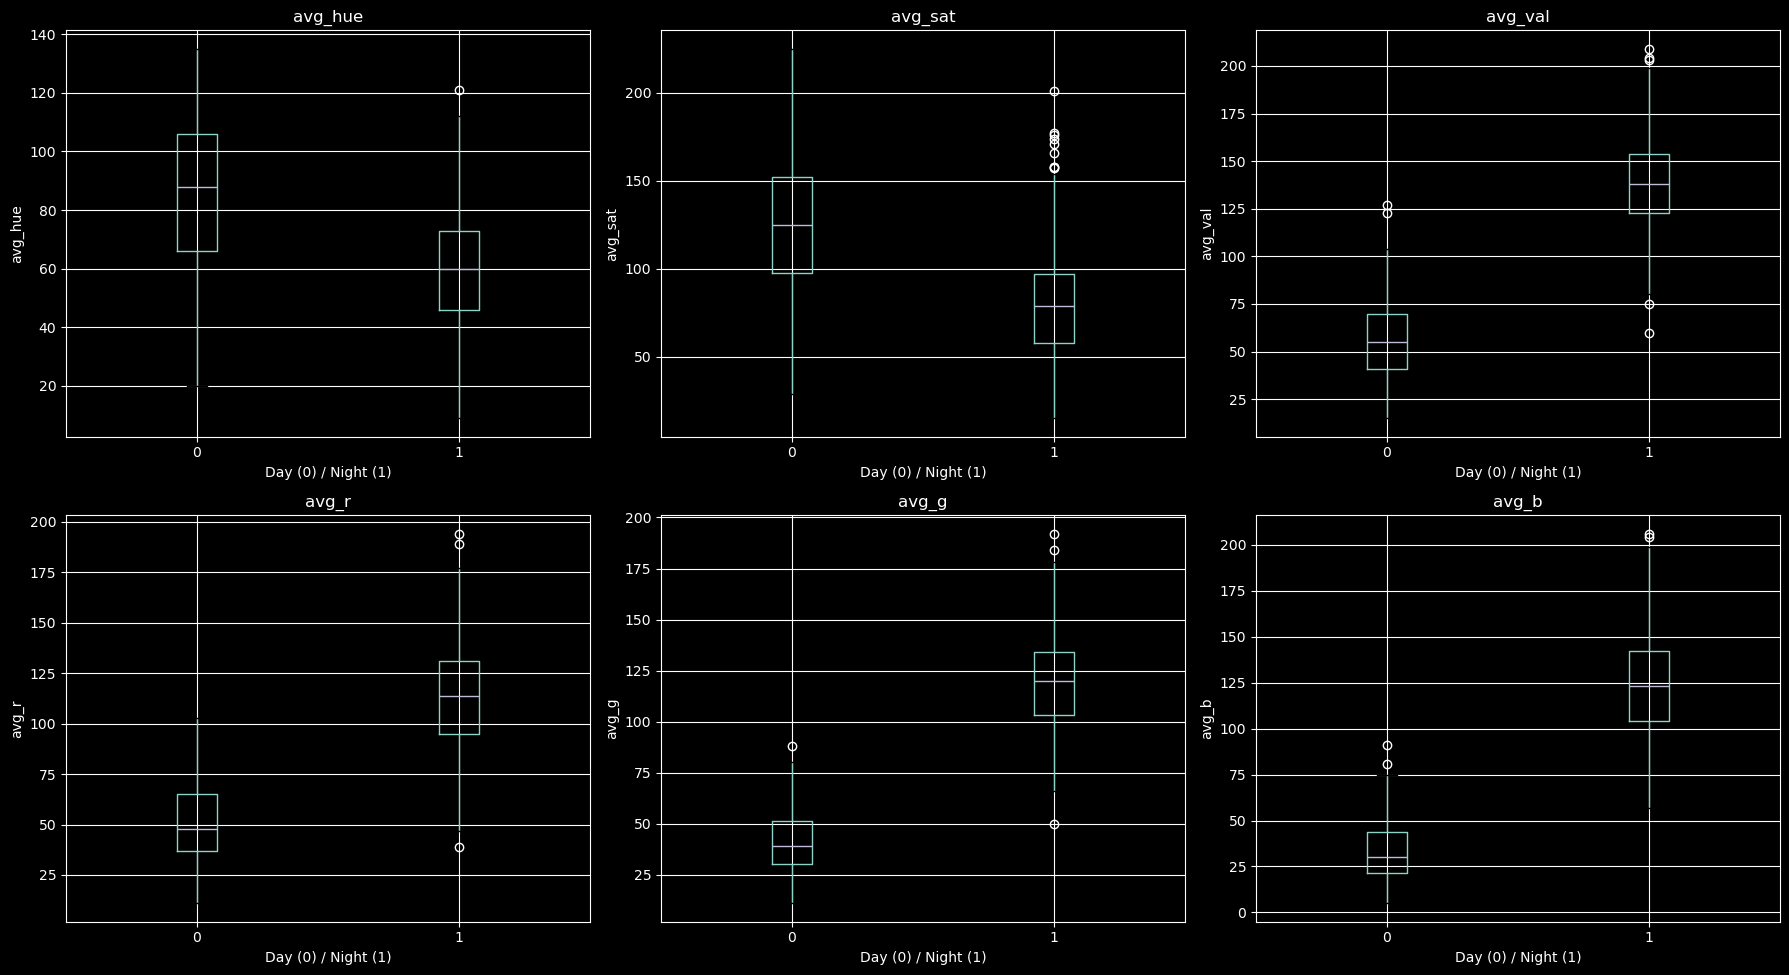

In [172]:
import matplotlib.pyplot as plt

features = ["avg_hue", "avg_sat", "avg_val", "avg_r", "avg_g", "avg_b"]
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3

    image_set.boxplot(column=feature, by="day_night", ax=ax[row][col])
    ax[row][col].set_title(feature)
    ax[row][col].set_xlabel("Day (0) / Night (1)")
    ax[row][col].set_ylabel(feature)

plt.suptitle("")
plt.tight_layout()
plt.show()

- `avg_val` (brightness) shows the strongest separation between day and night images
- RGB channel averages also show clear separations
- Hue and saturation provide weaker but complementary signals

In [173]:
# Splitting the data
from sklearn.model_selection import train_test_split

X = image_set.drop("day_night", axis=1)
y = image_set["day_night"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train_paths = X_train["filepath"]
X_test_paths = X_test["filepath"]

X_train = X_train.drop("filepath", axis=1)
X_test = X_test.drop("filepath", axis=1)

## 5. Preprocessing

In [174]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_features = ["avg_hue", "avg_sat", "avg_val", "avg_r", "avg_g", "avg_b"]
numeric_transform = StandardScaler()

preprocessor = ColumnTransformer([
    ("num", numeric_transform, numerical_features)
])

## 6. Choosing a model

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

model_dict = {
    "LogisticRegression": LogisticRegression(),
    "LinearSVC": LinearSVC(),
    "KNN": KNeighborsClassifier(),
    "RandomForestClassifier": RandomForestClassifier(random_state=42)
}

In [176]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision"
}

results = {}

for name, model in model_dict.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_res = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results[name] = {
        "accuracy_mean": np.mean(cv_res["test_accuracy"]),
        "recall_mean": np.mean(cv_res["test_recall"]),
        "precision_mean": np.mean(cv_res["test_precision"]),
    }

pd.DataFrame(results).T

,accuracy_mean,recall_mean,precision_mean
LogisticRegression,0.991653,0.992800,0.995238
LinearSVC,0.989986,0.990390,0.995238
KNN,0.989986,0.992828,0.992856
RandomForestClassifier,0.988333,0.990419,0.992828


### 5.1 Selecting `LinearSVC` and `LogisticRegression` for hyperparameter tuning

#### 5.1.1 `LinearSVC`

In [177]:
from sklearn.model_selection import GridSearchCV

svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearSVC())
])

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__loss': ['hinge', 'squared_hinge'],
    'model__max_iter': [1000, 2000],
    'model__tol': [1e-3, 1e-4, 1e-5]
}

grid_search_svc = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
)

grid_search_svc.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,Pipeline(step...LinearSVC())])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__loss': ['hinge', 'squared_hinge'], 'model__max_iter': [1000, 2000], 'model__penalty': ['l2'], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [178]:
best_svc_model = grid_search_svc.best_estimator_
best_y_preds_svc = best_svc_model.predict(X_test)

In [179]:
cv_svc_tuned = cross_validate(
    best_svc_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)


print(f"Change in Accuracy: \n\tOld: {results['LinearSVC']['accuracy_mean']}\n\tNew: {np.mean(cv_svc_tuned['test_accuracy'])}")
print(f"Change in Precision: \n\tOld: {results['LinearSVC']['precision_mean']}\n\tNew: {np.mean(cv_svc_tuned['test_precision'])}")
print(f"Change in Recall: \n\tOld: {results['LinearSVC']['recall_mean']}\n\tNew: {np.mean(cv_svc_tuned['test_recall'])}")

Change in Accuracy: 
	Old: 0.9899859943977593
	New: 0.9916526610644258
Change in Precision: 
	Old: 0.9952380952380953
	New: 0.9952380952380953
Change in Recall: 
	Old: 0.9903901319563971
	New: 0.9927997705106139


#### 5.1.2 `LogisticRegression`

In [180]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

param_grid = [
    {
        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "liblinear"],
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [1000]
    },
    {
        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["liblinear"],
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [1000]
    }
]

random_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
)

random_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 34 candidates, totalling 170 fits


,estimator,Pipeline(step...egression())])
,param_grid,"[{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__max_iter': [1000], 'model__penalty': ['l2'], ...}, {'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__max_iter': [1000], 'model__penalty': ['l1'], ...}]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [181]:
best_lr_model = random_search_lr.best_estimator_
best_y_preds_lr = best_lr_model.predict(X_test)

In [182]:
cv_lr_tuned = cross_validate(
    best_lr_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print(f"Change in Accuracy: \n\tOld: {results['LogisticRegression']['accuracy_mean']}\n\tNew: {np.mean(cv_lr_tuned['test_accuracy'])}")
print(f"Change in Precision: \n\tOld: {results['LogisticRegression']['precision_mean']}\n\tNew: {np.mean(cv_lr_tuned['test_precision'])}")
print(f"Change in Recall: \n\tOld: {results['LogisticRegression']['recall_mean']}\n\tNew: {np.mean(cv_lr_tuned['test_recall'])}")

Change in Accuracy: 
	Old: 0.9916526610644258
	New: 0.9933193277310923
Change in Precision: 
	Old: 0.9952380952380953
	New: 0.9952661064425771
Change in Recall: 
	Old: 0.9927997705106139
	New: 0.9951807228915662


The baseline model was already near optimal; tuning provided marginal gains.

# Selecting the `LogisticRegression`

In [183]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print(f"Final Accuracy: {accuracy_score(y_test, best_y_preds_lr)}")
print(f"Final Precision: {precision_score(y_test, best_y_preds_lr)}")
print(f"Final Recall: {recall_score(y_test, best_y_preds_lr)}")

Final Accuracy: 0.9933333333333333
Final Precision: 1.0
Final Recall: 0.9904761904761905


This is a relatively easy classification task due to strong brightness based signal

## Checking the misinterpreted images

In [184]:
y_preds = best_lr_model.predict(X_test)
misclassified_mask = y_preds != y_test

misclassified_paths = X_test_paths[misclassified_mask]
misclassified_true = y_test[misclassified_mask]
misclassified_pred = y_preds[misclassified_mask]

print(np.sum(misclassified_mask))

1


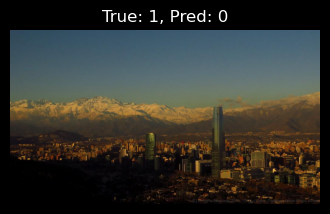

In [185]:
import matplotlib.image as mpimg

for path, true_label, pred_label in zip(misclassified_paths.head(10),misclassified_true.head(10),misclassified_pred[:10]):
    img = mpimg.imread(path)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")
    plt.show()

### Error Analysis
Only 1 image in the test set was misclassified
The image appears to depict a twilight scene with relatively low brightness and saturation, and because the model relies mainly on brightness to make decisions, it tends to misclassify images with moderate lighting, like those taken at dusk/dawn.